# Movie Genres Data Analysis

**Research Questions (Q)**
1. Which genres are the most common (number of movies made)?
2. Which genres have high avg. budget and revenue?
3. Which genres have a profit?
4. Which genres have high avg. popularity?
5. Which genres have highest number of movies with a voting avg. >= 8?


**Research Hypothesis (H)**
1. The best movies according to vote avg. return high profit and revenue.
2. The best movies according to popularity return high profit and revenue.
3. Highly budgeted movies return high revenue and profit.
4. Highly budgeted movies have a high popularity.
5. The profit per genre per year increases for some genres and decreases for others. 

In [1]:
import pandas as pd

### Start with cleaning the data
Open Data and take a look at the first few rows

In [2]:
movies = pd.read_csv("imdb_movies.csv")
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


I preferred to create a backup of data first. To prevent accidentally running the cell again, I will comment out the copy line after copying.

In [ ]:
# movies_backup = movies.copy()
movies_backup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

Look at the data amount and types

In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

Remove Duplicates

In [5]:
movies.drop_duplicates(inplace=True)
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


Next, we want to remove empty genre entries.

Note that after we remove the index count is the same as the genres count:

In [6]:
movies.dropna(subset = ['genres'], inplace=True)
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10842 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10842 non-null  int64  
 1   imdb_id               10834 non-null  object 
 2   popularity            10842 non-null  float64
 3   budget                10842 non-null  int64  
 4   revenue               10842 non-null  int64  
 5   original_title        10842 non-null  object 
 6   cast                  10767 non-null  object 
 7   homepage              2931 non-null   object 
 8   director              10800 non-null  object 
 9   tagline               8036 non-null   object 
 10  keywords              9367 non-null   object 
 11  overview              10839 non-null  object 
 12  runtime               10842 non-null  int64  
 13  genres                10842 non-null  object 
 14  production_companies  9826 non-null   object 
 15  release_date          10

We can add a column for profit:

In [7]:
movies['profit'] =  movies['revenue'] - movies['budget']
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,1363528810
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08,228436354
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08,185238201
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09,1868178225
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09,1316249360


We have a lot of unnecessary columns and want to reduce clutter as well.

In [8]:
movies_reduced = movies[['original_title', 'release_date', 'release_year', 'genres', 'budget', 'revenue', 'profit', 'popularity', 'runtime', 'vote_count', 'vote_average']]
movies_reduced.head()

,original_title,release_date,release_year,genres,budget,revenue,profit,popularity,runtime,vote_count,vote_average
0,Jurassic World,6/9/15,2015,Action|Adventure|Science Fiction|Thriller,150000000,1513528810,1363528810,32.985763,124,5562,6.5
1,Mad Max: Fury Road,5/13/15,2015,Action|Adventure|Science Fiction|Thriller,150000000,378436354,228436354,28.419936,120,6185,7.1
2,Insurgent,3/18/15,2015,Adventure|Science Fiction|Thriller,110000000,295238201,185238201,13.112507,119,2480,6.3
3,Star Wars: The Force Awakens,12/15/15,2015,Action|Adventure|Science Fiction|Fantasy,200000000,2068178225,1868178225,11.173104,136,5292,7.5
4,Furious 7,4/1/15,2015,Action|Crime|Thriller,190000000,1506249360,1316249360,9.335014,137,2947,7.3


Now, we will split up the genres as listed. Instead of keeping in this DataFrame, we will create a new DataFrame and use the ***primary keys*** from the movies_reduced as ***foreign keys*** in our new DataFrame of genres. This will make parsing the genre data easier.

In [9]:
from pandas import Series, DataFrame

In [10]:
genres_split = movies_reduced['genres'].str.split('|').apply(Series, 1).stack().reset_index(level=1, drop=True)

/tmp/ipykernel_209484/2098253242.py:1: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  genres_split = movies_reduced['genres'].str.split('|').apply(Series, 1).stack().reset_index(level=1, drop=True)


In [11]:
genres_split

0                 Action
0              Adventure
0        Science Fiction
0               Thriller
1                 Action
              ...       
10863            Mystery
10863             Comedy
10864             Action
10864             Comedy
10865             Horror
Length: 26955, dtype: object

For initial ease of exploration, we can recombine the genres_split DataFrame to the original movies DataFrame, but for compute, it would be faster to use more complex queries.

***Secondary Task: later, go back and check the compute time using more complex queries***

In [12]:
genres_split.name = 'genres_split'
del movies_reduced['genres']
movies_reduced = movies_reduced.join(genres_split)
movies_reduced.head(10)

,original_title,release_date,release_year,budget,revenue,profit,popularity,runtime,vote_count,vote_average,genres_split
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.985763,124,5562,6.5,Action
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.985763,124,5562,6.5,Adventure
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.985763,124,5562,6.5,Science Fiction
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.985763,124,5562,6.5,Thriller
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.419936,120,6185,7.1,Action
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.419936,120,6185,7.1,Adventure
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.419936,120,6185,7.1,Science Fiction
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.419936,120,6185,7.1,Thriller
2,Insurgent,3/18/15,2015,110000000,295238201,185238201,13.112507,119,2480,6.3,Adventure
2,Insurgent,3/18/15,2015,110000000,295238201,185238201,13.112507,119,2480,6.3,Science Fiction


## Now to answering the research questions:

1. Which genres are the most common (number of movies made)?

Compare these two methods of sorting the data. The first leaves us with a series, the second with a pandas DataFrame, which is the format we really want in this case.

In [13]:
movies_common = movies_reduced.groupby('genres_split')['original_title'].count().sort_values(ascending=False)

In [14]:
genres_count = pd.DataFrame(movies_reduced.groupby('genres_split').original_title.nunique()).sort_values('original_title',ascending=True)

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: title={'center': 'Movies Per Genre in %'}, ylabel='original_title'>

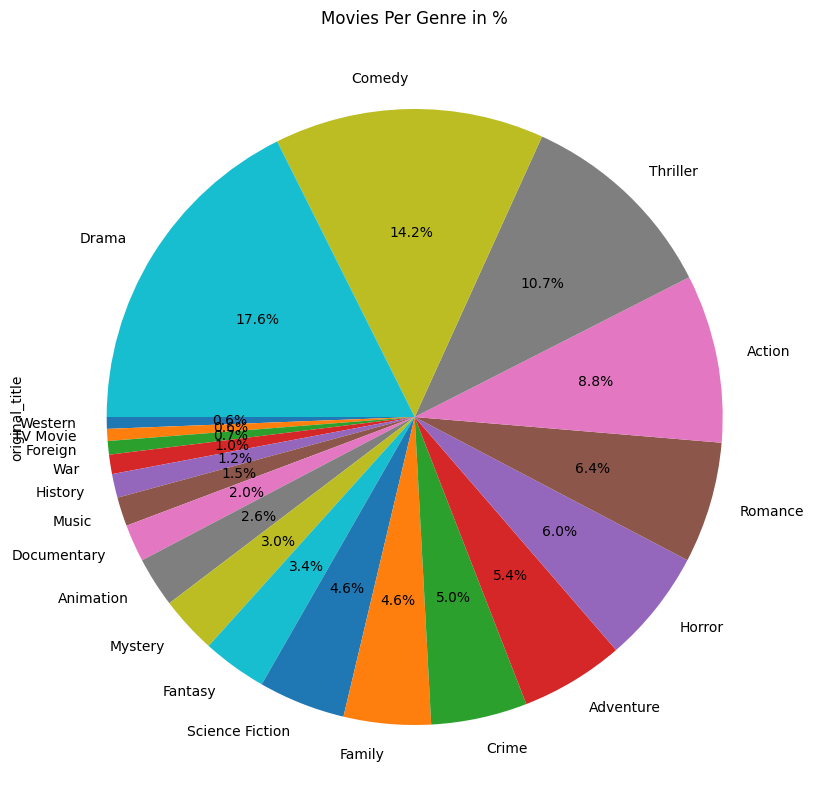

In [16]:
genres_count['original_title'].plot.pie(title= 'Movies Per Genre in %', autopct='%1.1f%%', figsize=(10,10), startangle=180)

<Axes: title={'center': 'Movies per Genre'}, ylabel='genres_split'>

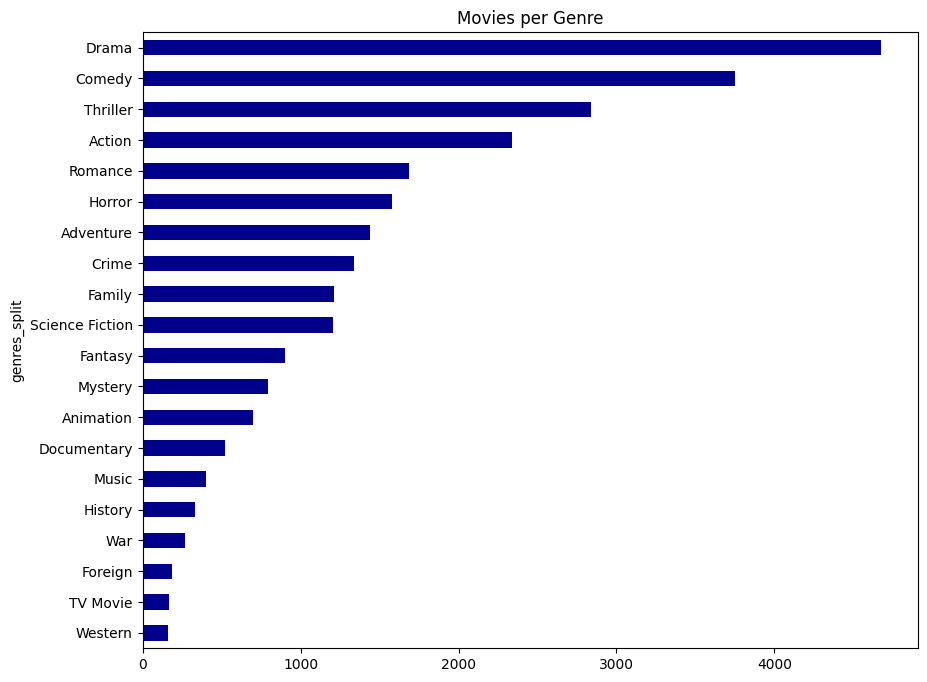

In [17]:
genres_count['original_title'].plot.barh(title = 'Movies per Genre', color='darkblue', figsize=(10,8))

2. Which genres have high avg. budget and revenue?


In [18]:
genres_avg = pd.DataFrame(movies_reduced.groupby('genres_split').mean(numeric_only=True))
pd.options.display.float_format = '{:,.2f}'.format
genres_avg 

,release_year,budget,revenue,profit,popularity,runtime,vote_count,vote_average
genres_split,,,,,,,,
Action,"2,000.06","27,727,820.33","72,794,732.00","45,066,911.67",0.93,104.92,392.99,5.79
Adventure,"1,999.39","37,543,694.53","113,137,861.07","75,594,166.54",1.15,106.17,513.13,5.94
Animation,"2,004.00","23,159,781.61","75,256,062.22","52,096,280.62",0.85,68.18,303.00,6.40
Comedy,"2,000.82","13,297,915.62","37,526,242.07","24,228,326.45",0.59,96.75,176.44,5.91
Crime,"1,999.49","17,663,801.12","42,368,661.65","24,704,860.52",0.74,106.92,278.81,6.12
Documentary,"2,008.31","577,149.15","2,041,106.99","1,463,957.85",0.18,102.65,35.11,6.91
Drama,"2,000.93","11,880,717.77","29,232,255.73","17,351,537.95",0.59,110.48,182.54,6.17
Family,"2,000.77","23,359,337.42","72,433,176.37","49,073,838.95",0.79,89.60,272.32,6.00
Fantasy,"2,000.29","32,612,585.35","96,313,657.08","63,701,071.73",0.99,100.74,420.74,5.86


<Axes: title={'center': 'Budget & Revenue per Genre, sorted by Budget'}, ylabel='genres_split'>

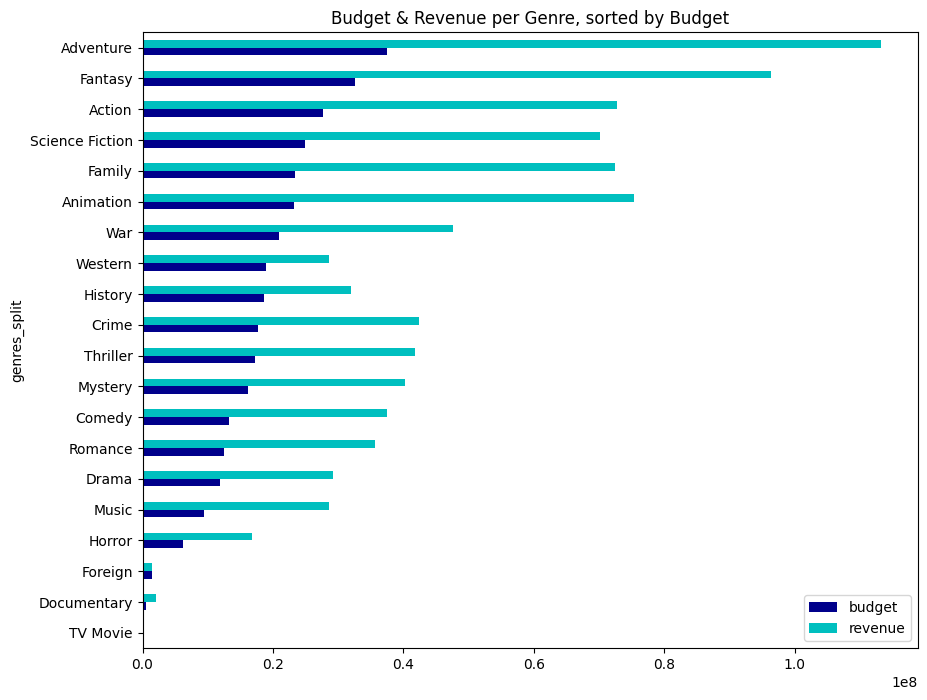

In [19]:
genres_budget = genres_avg.sort_values(['budget'], ascending=True)
genres_budget[['budget','revenue']].plot.barh(title = 'Budget & Revenue per Genre, sorted by Budget', color=('darkblue','c'), figsize=(10,8))

<Axes: title={'center': 'Budget & Revenue per Genre, sorted by Revenue'}, ylabel='genres_split'>

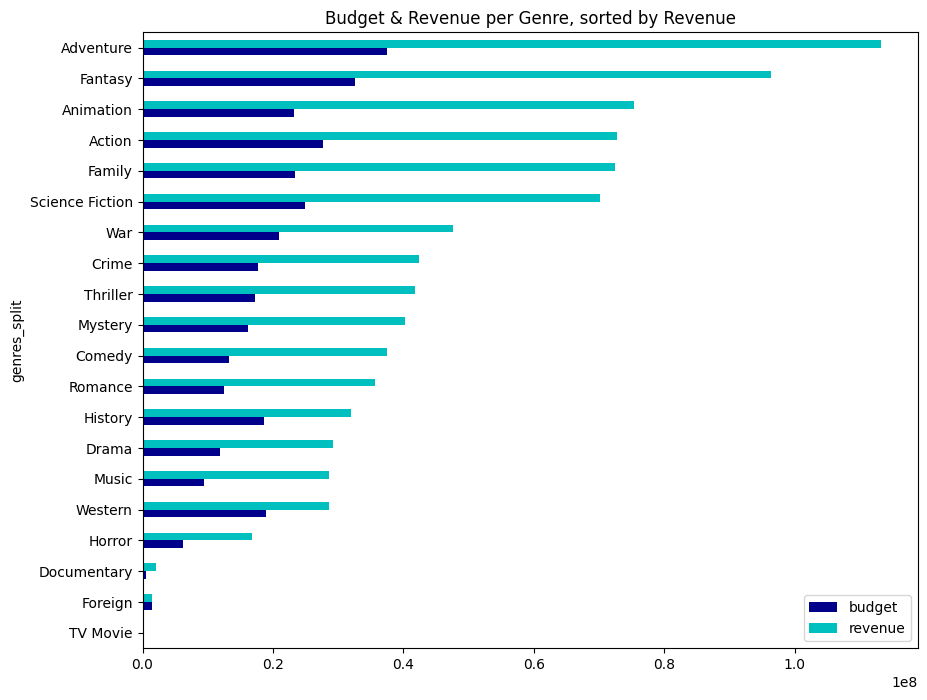

In [20]:
genres_budget = genres_avg.sort_values(['revenue'], ascending=True)
genres_budget[['budget','revenue']].plot.barh(title = 'Budget & Revenue per Genre, sorted by Revenue', color=('darkblue','c'), figsize=(10,8))

3. Which genres have a profit?


<Axes: title={'center': 'Average Profit per Genre'}, ylabel='genres_split'>

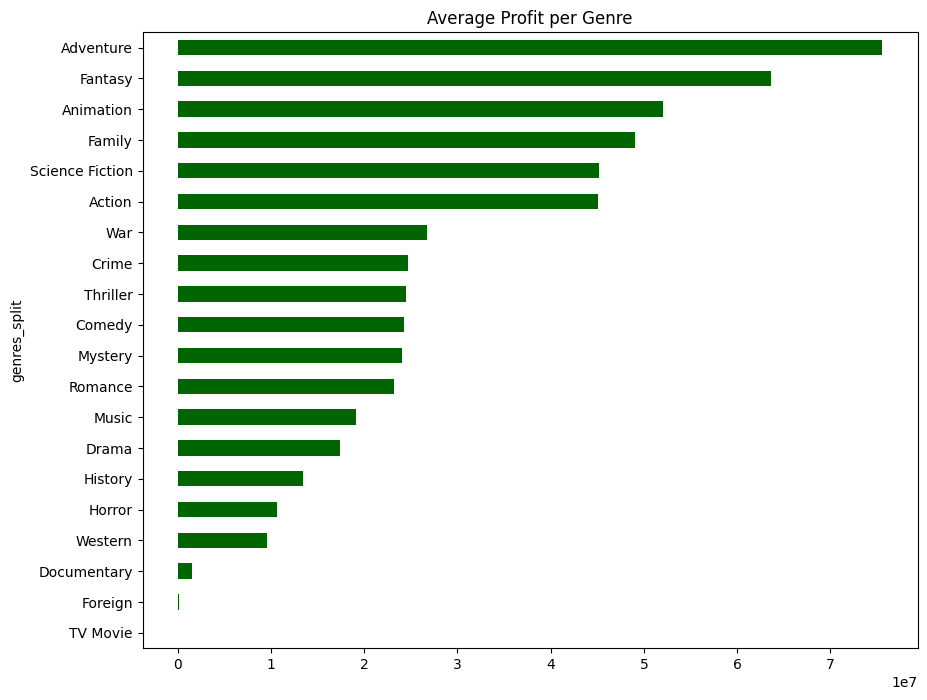

In [21]:
genres_avg.sort_values('profit', ascending=True, inplace=True)
genres_avg['profit'].plot.barh(title = 'Average Profit per Genre', color='darkgreen', figsize=(10,8))

4. Which genres have high avg. popularity?


In [22]:
movies_reduced.head()

,original_title,release_date,release_year,budget,revenue,profit,popularity,runtime,vote_count,vote_average,genres_split
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Action
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Adventure
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Science Fiction
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Thriller
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.42,120,6185,7.10,Action


<Axes: title={'center': 'Average Popularity per Genre'}, ylabel='genres_split'>

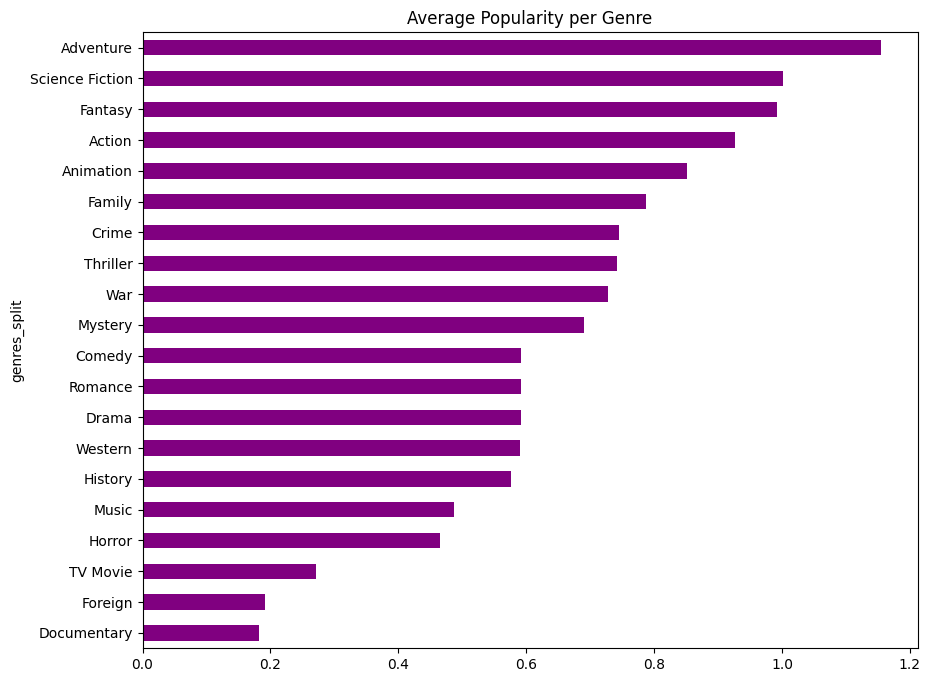

In [23]:
genres_avg.sort_values('popularity', ascending=True, inplace=True)
genres_avg['popularity'].plot.barh(title = 'Average Popularity per Genre', color='purple', figsize=(10,8))

5. Which genres have highest number of movies with a voting avg. >= 3.8?

We want to offset and adjust this to exclude genres with small vote counts. Those values wouldn't accurately represent large enough populations.

In [24]:
vote_sample = movies_reduced[(movies_reduced['vote_average'] >=8.0) & (movies_reduced['vote_count'] >= 50)]
vote_sample.head()

,original_title,release_date,release_year,budget,revenue,profit,popularity,runtime,vote_count,vote_average,genres_split
9,Inside Out,6/9/15,2015,175000000,853708609,678708609,6.33,94,3935,8.00,Comedy
9,Inside Out,6/9/15,2015,175000000,853708609,678708609,6.33,94,3935,8.00,Animation
9,Inside Out,6/9/15,2015,175000000,853708609,678708609,6.33,94,3935,8.00,Family
35,Room,10/16/15,2015,6000000,35401758,29401758,3.56,117,1520,8.00,Drama
35,Room,10/16/15,2015,6000000,35401758,29401758,3.56,117,1520,8.00,Thriller


In [25]:
genres_vote = pd.DataFrame(vote_sample.groupby('genres_split').original_title.nunique()).sort_values('original_title',ascending=True)
genres_vote.rename(columns={'original_title':'num_movies'}, inplace=True)
genres_vote

,num_movies
genres_split,
Mystery,1
Horror,1
Fantasy,2
History,2
Music,2
Action,3
Romance,3
Comedy,3
Science Fiction,3


<Axes: title={'center': 'Number of Movies per Genre (High Vote Average)'}, ylabel='genres_split'>

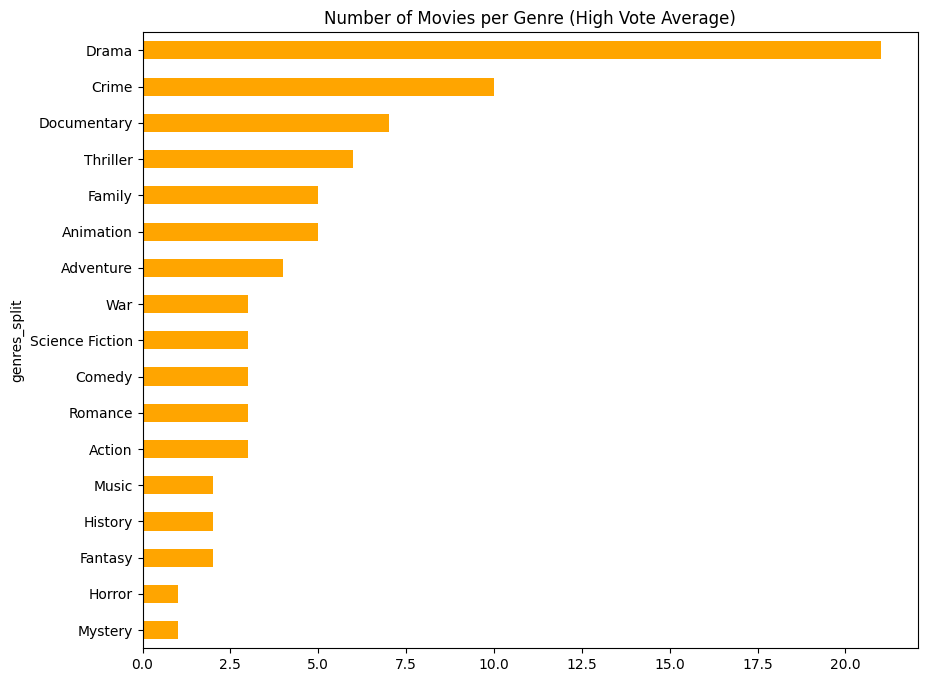

In [26]:
genres_vote['num_movies'].plot.barh(title = 'Number of Movies per Genre (High Vote Average)', color='orange', figsize=(10,8))    

## Now we want to analyze our Hypotheses


In [27]:
movies.head()
movies


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit
0,135397,tt0369610,32.99,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.50,2015,"137,999,939.28","1,392,445,892.52",1363528810
1,76341,tt1392190,28.42,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.10,2015,"137,999,939.28","348,161,292.49",228436354
2,262500,tt2908446,13.11,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.30,2015,"101,199,955.47","271,619,025.41",185238201
3,140607,tt2488496,11.17,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.50,2015,"183,999,919.04","1,902,723,129.80",1868178225
4,168259,tt2820852,9.34,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.30,2015,"174,799,923.09","1,385,748,801.47",1316249360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10861,21,tt0060371,0.08,0,0,The Endless Summer,Michael Hynson|Robert August|Lord 'Tally Ho' B...,NaN,Bruce Brown,NaN,...,95,Documentary,Bruce Brown Films,6/15/66,11,7.40,1966,0.00,0.00,0
10862,20379,tt0060472,0.07,0,0,Grand Prix,James Garner|Eva Marie Saint|Yves Montand|Tosh...,NaN,John Frankenheimer,Cinerama sweeps YOU into a drama of speed and ...,...,176,Action|Adventure|Drama,Cherokee Productions|Joel Productions|Douglas ...,12/21/66,20,5.70,1966,0.00,0.00,0
10863,39768,tt0060161,0.07,0,0,Beregis Avtomobilya,Innokentiy Smoktunovskiy|Oleg Efremov|Georgi Z...,NaN,Eldar Ryazanov,NaN,...,94,Mystery|Comedy,Mosfilm,1/1/66,11,6.50,1966,0.00,0.00,0
10864,21449,tt0061177,0.06,0,0,"What's Up, Tiger Lily?",Tatsuya Mihashi|Akiko Wakabayashi|Mie Hama|Joh...,NaN,Woody Allen,WOODY ALLEN STRIKES BACK!,...,80,Action|Comedy,Benedict Pictures Corp.,11/2/66,22,5.40,1966,0.00,0.00,0


In [28]:
movies_counted = movies[movies['vote_count'] >= 50]
movies_counted = movies_counted[['popularity','vote_average','vote_count','genres','original_title', 'release_date', 'release_year', 'budget', 'revenue', 'profit', 'runtime']]
movies_counted.corr(method='spearman', numeric_only=True)

,popularity,vote_average,vote_count,release_year,budget,revenue,profit,runtime
popularity,1.00,0.19,0.77,0.07,0.48,0.59,0.50,0.23
vote_average,0.19,1.00,0.29,-0.15,-0.04,0.11,0.20,0.29
vote_count,0.77,0.29,1.00,0.15,0.55,0.68,0.58,0.26
release_year,0.07,-0.15,0.15,1.00,-0.02,-0.11,-0.10,-0.13
budget,0.48,-0.04,0.55,-0.02,1.00,0.71,0.33,0.36
revenue,0.59,0.11,0.68,-0.11,0.71,1.00,0.84,0.34
profit,0.50,0.20,0.58,-0.10,0.33,0.84,1.00,0.21
runtime,0.23,0.29,0.26,-0.13,0.36,0.34,0.21,1.00


Hypothesis 1. The best movies according to vote avg. return high profit and revenue.


<Axes: xlabel='vote_average', ylabel='profit'>

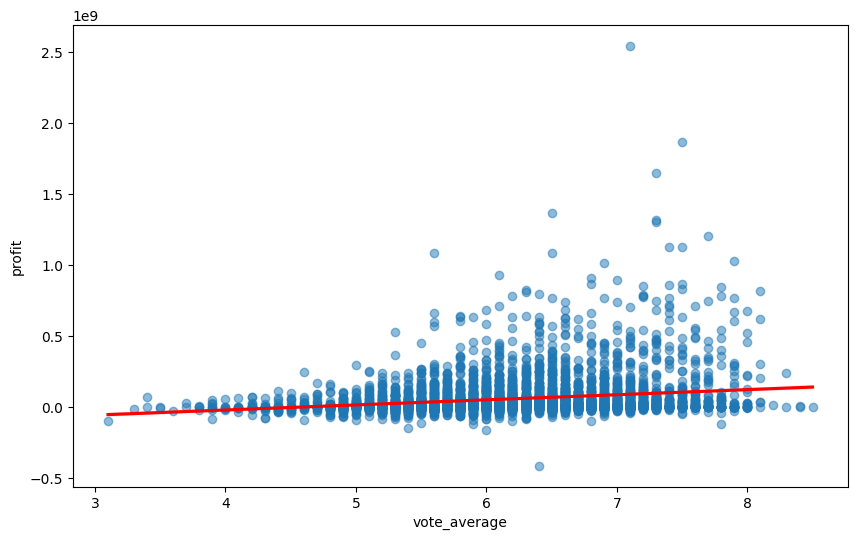

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'vote_average', y = 'profit', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'} )

<Axes: xlabel='vote_average', ylabel='revenue'>

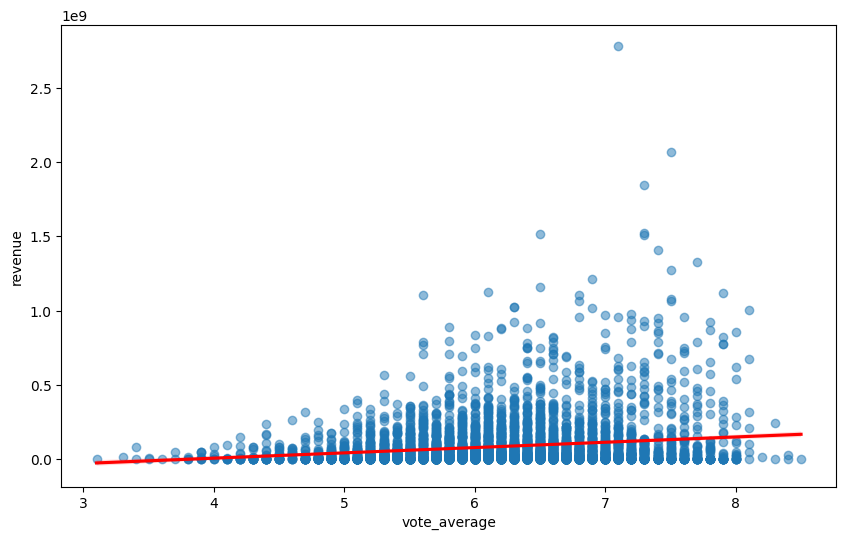

In [30]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'vote_average', y = 'revenue', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

Analysis, the correlation is positive, however, it is not as high as we would have expected.

Hypothesis 2. The best movies according to popularity return high profit and revenue.


<Axes: xlabel='popularity', ylabel='revenue'>

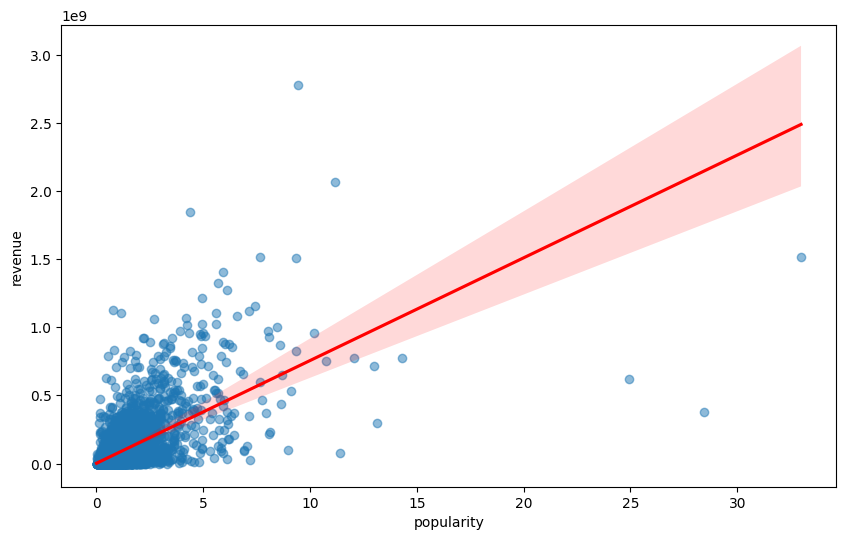

In [31]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'popularity', y = 'revenue', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

<Axes: xlabel='popularity', ylabel='profit'>

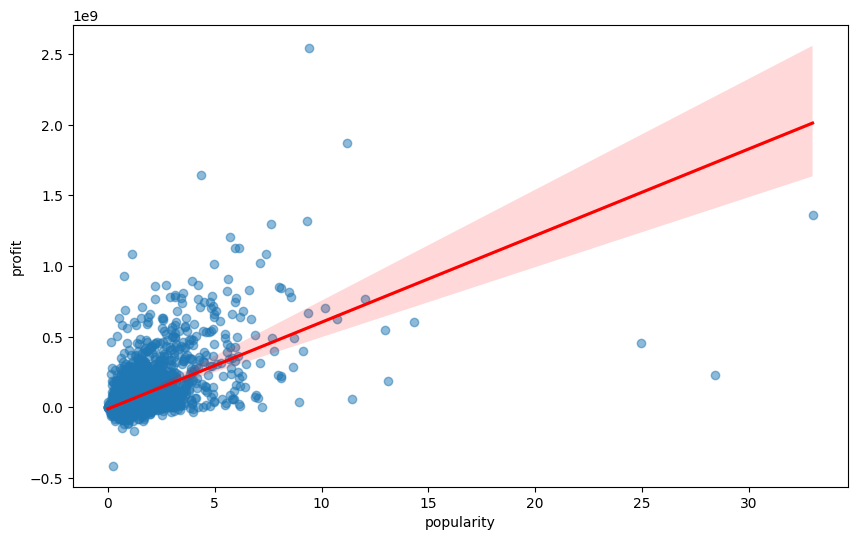

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'popularity', y = 'profit', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

Analysis: There is a much higher correlation between popularity and revenue as well as popularity and profit.

3. Highly budgeted movies return high revenue and profit.


<Axes: xlabel='budget', ylabel='profit'>

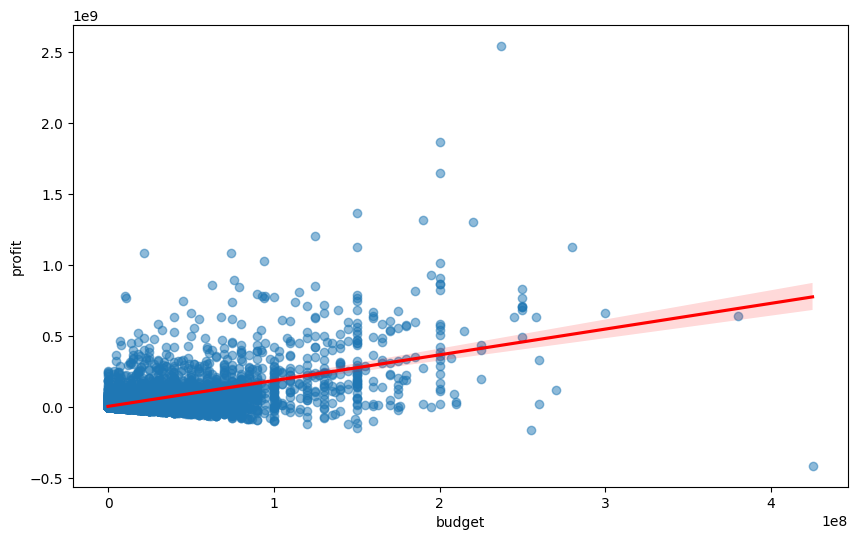

In [33]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'budget', y = 'profit', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

<Axes: xlabel='budget', ylabel='revenue'>

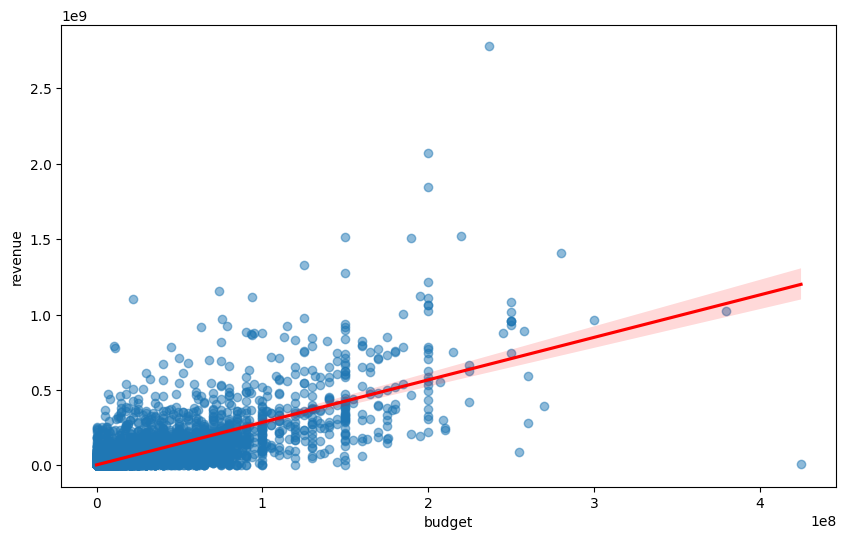

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'budget', y = 'revenue', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

Analysis: as we expect, highly budgeted movies have higher revenue and profit.

4. Highly budgeted movies have a high popularity.

<Axes: xlabel='budget', ylabel='popularity'>

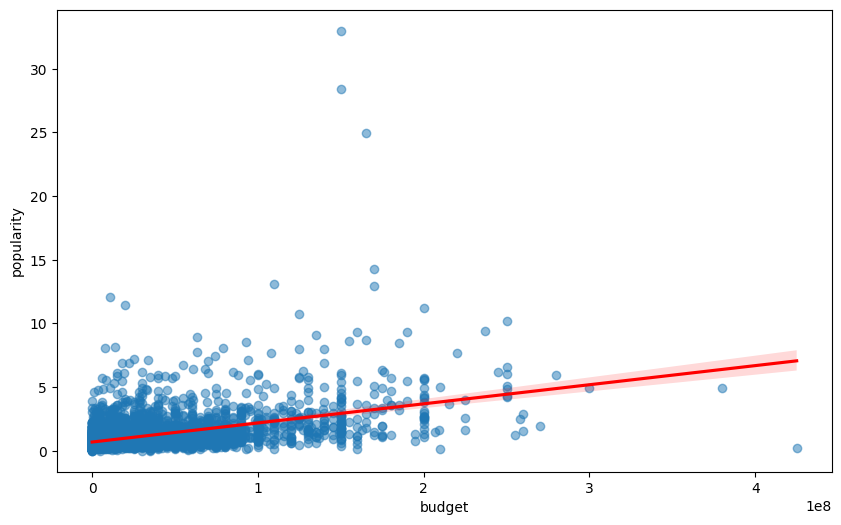

In [35]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(x = 'budget', y = 'popularity', data=movies_counted, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

Analysis: again, as we expected, higher budgets have higher popularity.

Hypothesis 5. The profit per genre per year increases for some genres and decreases for others.

In [39]:
movies_reduced.head()

,original_title,release_date,release_year,budget,revenue,profit,popularity,runtime,vote_count,vote_average,genres_split
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Action
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Adventure
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Science Fiction
0,Jurassic World,6/9/15,2015,150000000,1513528810,1363528810,32.99,124,5562,6.50,Thriller
1,Mad Max: Fury Road,5/13/15,2015,150000000,378436354,228436354,28.42,120,6185,7.10,Action


In [41]:
time_genre = pd.DataFrame(movies_reduced.groupby(['release_year', 'genres_split'])['profit'].mean())  
time_genre.head(20)


profit
release_year genres_split                  
1960         Action            6,363,125.00
             Adventure           431,000.00
             Comedy            5,258,750.00
             Crime                     0.00
             Drama             8,245,619.38
             Family            3,333,333.33
             Fantasy            -375,000.00
             Foreign                   0.00
             History           9,600,000.00
             Horror            4,389,007.43
             Music                     0.00
             Romance           5,225,000.00
             Science Fiction    -316,666.67
             Thriller          5,028,842.00
             War                       0.00
             Western             484,166.67
1961         Action            2,457,142.86
             Adventure        39,130,002.33
             Animation       211,880,014.00
             Comedy           22,198,001.40

In [44]:
yearly_genre = pd.pivot_table(time_genre, values='profit', index='genres_split', columns='release_year')

Text(0.5, 1.0, 'Profit by Genre over Years')

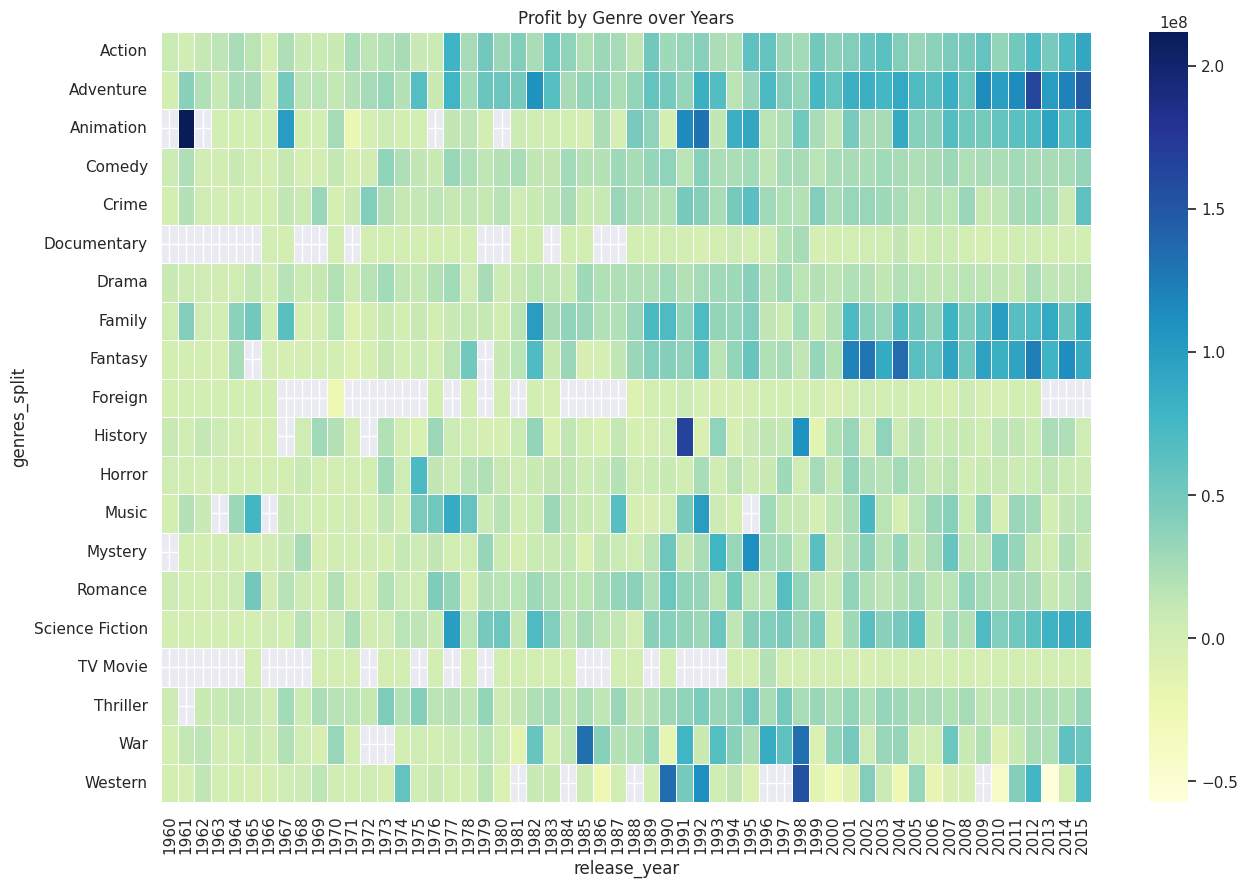

In [53]:
sns.set(rc = {'figure.figsize':(15,10)})
sns.heatmap(yearly_genre, cmap='YlGnBu', linecolor='white', linewidths=0.5) 
plt.title('Profit by Genre over Years')